In [2]:
import pandas as pd
import sqlite3

db_path = "SQLite-db/sessions.db"
conn = sqlite3.connect(db_path)

A synthetic viewer becomes active once matching digital volume reaches at least half of its weight.

In [92]:
weights_df = pd.read_sql("""
SELECT *
FROM digital_20250904_activation_weights
""", conn)
weights_df

,ts,target_group,channel_id,channel_weight,target_group_weight
0,2025-09-04 01:00:00,f1229,0,1,1
1,2025-09-04 01:00:00,f1229,3100,1,3
2,2025-09-04 01:00:00,f1229,3100,2,5
3,2025-09-04 01:00:00,f1229,3100,3,6
4,2025-09-04 01:00:00,f1229,3301,1,4
...,...,...,...,...,...
1494351,2025-09-05 01:00:00,mover50,3402,0,5
1494352,2025-09-05 01:00:00,mover50,3403,3,156
1494353,2025-09-05 01:00:00,mover50,3403,2,155
1494354,2025-09-05 01:00:00,mover50,3403,1,77


In [93]:
weights_df["ts"] = pd.to_datetime(weights_df["ts"])

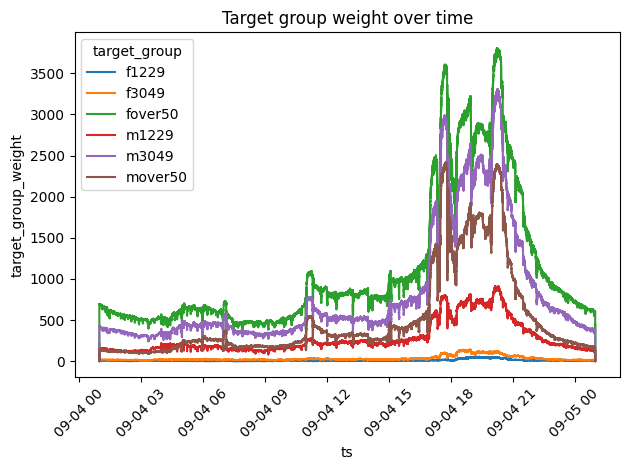

In [94]:
import matplotlib.pyplot as plt

df = weights_df.sort_values("ts")

for group, g in df.groupby("target_group"):
    plt.plot(g["ts"], g["target_group_weight"], label=group)

plt.xlabel("ts")
plt.ylabel("target_group_weight")
plt.title("Target group weight over time")
plt.legend(title="target_group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()